<a href="https://colab.research.google.com/github/johnsparz/ai-bootcamp-portfolio_3/blob/master/Heart_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Heart Disease Prediction Using Logistic Regression**

**Step 1: Import Libraries**

In [7]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

**Step 2: Load and Explore Dataset**

In [8]:
df = pd.read_csv('heart_disease.csv')

In [9]:
#Check shape
df.shape

(1025, 14)

In [10]:
#View columns
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [11]:
#Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [12]:
#Check missing values
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [13]:
#Statistical summary
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


**Step 3: Check Target Distribution**

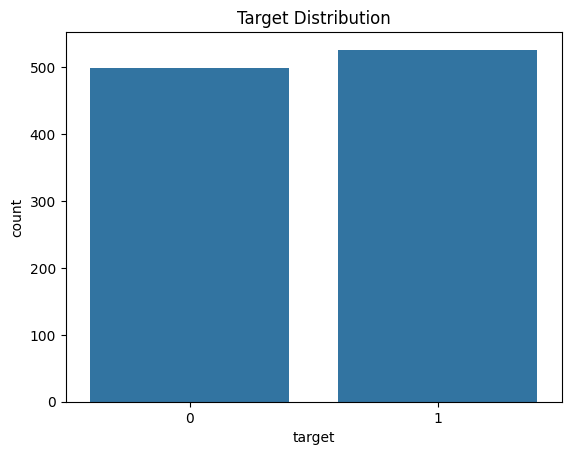

In [14]:
sns.countplot(x='target', data=df)
plt.title("Target Distribution")
plt.show()

**Step 4: Feature and Target Separation**

In [15]:
X = df.drop("target", axis=1)

y = df["target"]

**Step 5: Split Dataset**

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(820, 13)
(205, 13)


**Step 6: Train Logistic Regression Model**

In [17]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

**Step 7: Make Predictions**

In [18]:
y_pred = model.predict(X_test)

y_pred[:10]

array([1, 1, 0, 1, 0, 1, 0, 0, 1, 0])

**Step 8: Evaluate Model**

In [19]:
#Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7951219512195122


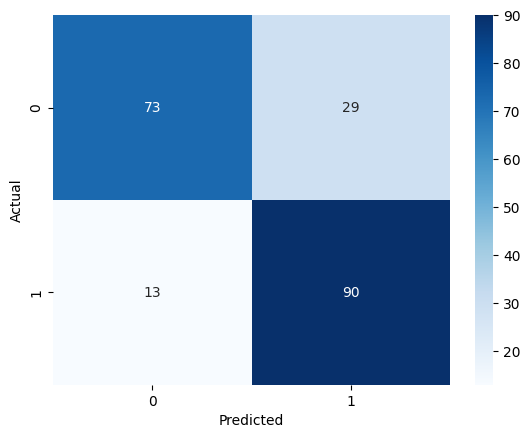

In [20]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [21]:
#Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205



**Step 9: Save Model**

In [22]:
import pickle

pickle.dump(
    model,
    open("heart_model.pkl", "wb")
)

**Step 10: Test Saved Model**

In [23]:
loaded_model = pickle.load(
    open("heart_model.pkl", "rb")
)

prediction = loaded_model.predict(X_test)

print(prediction[:5])

[1 1 0 1 0]


**Step 11: Install Streamlit and Ngrok**

In [24]:
!pip install streamlit pyngrok

In [25]:
!streamlit run app.py &>/content/logs.txt &

**Step 12: Create app.py**

In [33]:
%%writefile app.py

import streamlit as st
import pickle
import numpy as np

model = pickle.load(open("heart_model.pkl", "rb"))

st.title("Heart Disease Prediction System")

st.write("Enter patient information below.")

age = st.number_input("Age", 20, 100, 50)
sex = st.selectbox("Sex", [0, 1])
cp = st.number_input("Chest Pain Type", 0, 3, 0)
trestbps = st.number_input("Resting Blood Pressure", 80, 250, 120)
chol = st.number_input("Cholesterol", 100, 600, 200)
fbs = st.selectbox("Fasting Blood Sugar", [0, 1])
restecg = st.number_input("Rest ECG", 0, 2, 0)
thalach = st.number_input("Max Heart Rate", 50, 250, 150)
exang = st.selectbox("Exercise Induced Angina", [0, 1])
oldpeak = st.number_input("Oldpeak", 0.0, 10.0, 1.0)
slope = st.number_input("Slope", 0, 2, 1)
ca = st.number_input("Major Vessels", 0, 4, 0)
thal = st.number_input("Thal", 0, 3, 2)

if st.button("Predict"):

    data = np.array([[
        age,
        sex,
        cp,
        trestbps,
        chol,
        fbs,
        restecg,
        thalach,
        exang,
        oldpeak,
        slope,
        ca,
        thal
    ]])

    prediction = model.predict(data)

    if prediction[0] == 1:
        st.error("Heart Disease Detected")
    else:
        st.success("No Heart Disease Detected")

Writing app.py


In [29]:
from pyngrok import ngrok

ngrok.set_auth_token("3FBMNQVnQ5FHIYvXFNDlTisTk8J_5gU6i8aMcTcBWhuKcvzpH")

In [34]:
!streamlit run app.py &>/content/logs.txt &

**Step 13: Create Public URL**

In [35]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://filtrate-untracked-overcrowd.ngrok-free.dev" -> "http://localhost:8501"


In [36]:
!ls -l


total 56
-rw-r--r-- 1 root root  1253 Jun 15 17:32 app.py
-rw-r--r-- 1 root root 38114 Jun 15 17:15 heart_disease.csv
-rw-r--r-- 1 root root  1006 Jun 15 17:15 heart_model.pkl
-rw-r--r-- 1 root root   321 Jun 15 17:32 logs.txt
drwxr-xr-x 1 root root  4096 Jun  4 13:32 sample_data
